# Recuperación de Oro — Proyecto de Machine Learning
**Objetivo:** Predecir el coeficiente de recuperación de oro en distintas etapas del proceso de purificación, usando datos de procesos de flotación.

**Métrica de evaluación:**
$$\text{sMAPE} = \frac{1}{N}\sum_{i=1}^{N} \frac{|y_i - \hat{y}_i|}{(|y_i| + |\hat{y}_i|)/2} \times 100\%$$

$$\text{sMAPE}_{\text{final}} = 25\% \times \text{sMAPE}(\text{rougher}) + 75\% \times \text{sMAPE}(\text{final})$$

---
## 1. Preparación de los Datos

### 1.1 Apertura y exploración de los archivos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

# Cargar datasets
train = pd.read_csv('../data/gold_recovery_train.csv')
test  = pd.read_csv('../data/gold_recovery_test.csv')
full  = pd.read_csv('../data/gold_recovery_full.csv')

print('=== TRAIN ===')
print(f'Shape: {train.shape}')
train.head(3)

=== TRAIN ===
Shape: (16860, 87)


,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363


In [3]:
print('=== TEST ===')
print(f'Shape: {test.shape}')
test.head(3)

=== TEST ===
Shape: (5856, 53)


,date,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-09-01 00:59:59,210.800909,14.993118,8.080000,1.005021,1398.981301,-500.225577,1399.144926,-499.919735,1400.102998,...,12.023554,-497.795834,8.016656,-501.289139,7.946562,-432.317850,4.872511,-500.037437,26.705889,-499.709414
1,2016-09-01 01:59:59,215.392455,14.987471,8.080000,0.990469,1398.777912,-500.057435,1398.055362,-499.778182,1396.151033,...,12.058140,-498.695773,8.130979,-499.634209,7.958270,-525.839648,4.878850,-500.162375,25.019940,-499.819438
2,2016-09-01 02:59:59,215.259946,12.884934,7.786667,0.996043,1398.493666,-500.868360,1398.860436,-499.764529,1398.075709,...,11.962366,-498.767484,8.096893,-500.827423,8.071056,-500.801673,4.905125,-499.828510,24.994862,-500.622559


In [4]:
print('=== FULL ===')
print(f'Shape: {full.shape}')
full.head(3)

=== FULL ===
Shape: (22716, 87)


,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363


### 1.2 Verificación del cálculo de recuperación (`rougher.output.recovery`)

In [5]:
# Fórmula de recuperación:
# recovery = C*(F - T) / (F*(C - T)) * 100
# donde:
#   C = concentración del metal en el concentrado rougher output
#   F = concentración del metal en la alimentación rougher input
#   T = concentración del metal en las colas rougher output

C = train['rougher.output.concentrate_au']
F = train['rougher.input.feed_au']
T = train['rougher.output.tail_au']

# Calcular recuperación manualmente
recovery_calc = C * (F - T) / (F * (C - T)) * 100

# Valor real
recovery_real = train['rougher.output.recovery']

# EAM (Error Absoluto Medio)
mask = recovery_real.notna() & recovery_calc.notna() & np.isfinite(recovery_calc)
mae = np.abs(recovery_calc[mask] - recovery_real[mask]).mean()

print(f'EAM entre recuperación calculada y la columna original: {mae:.6f}')


EAM entre recuperación calculada y la columna original: 0.000000


El EAM es practicamente 0, lo que confirma que el cáculo es corecto 

### 1.3 Características no disponibles en el conjunto de prueba

In [6]:
# Columnas en train que NO están en test
missing_in_test = set(train.columns) - set(test.columns)
print(f'Número de características ausentes en test: {len(missing_in_test)}')
print()

missing_df = pd.DataFrame({'columna': sorted(missing_in_test)})

# Clasificar por tipo (target vs. proceso)
targets = [c for c in missing_in_test if 'recovery' in c]
process = [c for c in missing_in_test if 'recovery' not in c]

print('--- Variables objetivo (targets) ---')
for t in sorted(targets):
    print(f'  {t}')

print()
print('--- Variables de proceso no medidas en tiempo real ---')
for p in sorted(process):
    print(f'  {p}')


Número de características ausentes en test: 34

--- Variables objetivo (targets) ---
  final.output.recovery
  rougher.output.recovery

--- Variables de proceso no medidas en tiempo real ---
  final.output.concentrate_ag
  final.output.concentrate_au
  final.output.concentrate_pb
  final.output.concentrate_sol
  final.output.tail_ag
  final.output.tail_au
  final.output.tail_pb
  final.output.tail_sol
  primary_cleaner.output.concentrate_ag
  primary_cleaner.output.concentrate_au
  primary_cleaner.output.concentrate_pb
  primary_cleaner.output.concentrate_sol
  primary_cleaner.output.tail_ag
  primary_cleaner.output.tail_au
  primary_cleaner.output.tail_pb
  primary_cleaner.output.tail_sol
  rougher.calculation.au_pb_ratio
  rougher.calculation.floatbank10_sulfate_to_au_feed
  rougher.calculation.floatbank11_sulfate_to_au_feed
  rougher.calculation.sulfate_to_au_concentrate
  rougher.output.concentrate_ag
  rougher.output.concentrate_au
  rougher.output.concentrate_pb
  rougher.output.

Los targets (**rougher.output.recovery** y **final.output.recovery**) son los que el modelo debe predecir. Las demás columnas son las mediciones que no están disponibles en producción en el momento de hacer la predicción.

### 1.4 Preprocesamiento de datos

In [7]:
# Revisar valores nulos en train y test
print('Valores nulos en TRAIN:')
null_train = train.isnull().sum()
print(null_train[null_train > 0].sort_values(ascending=False).head(20))

print()
print('Valores nulos en TEST:')
null_test = test.isnull().sum()
print(null_test[null_test > 0].sort_values(ascending=False).head(20))

Valores nulos en TRAIN:
rougher.output.recovery                     2573
rougher.output.tail_ag                      2250
rougher.output.tail_au                      2249
rougher.output.tail_sol                     2249
secondary_cleaner.output.tail_sol           1986
rougher.input.floatbank11_xanthate          1904
final.output.recovery                       1521
primary_cleaner.input.sulfate               1307
primary_cleaner.input.depressant            1262
rougher.calculation.au_pb_ratio             1242
rougher.input.floatbank10_sulfate           1044
primary_cleaner.input.xanthate               985
primary_cleaner.output.concentrate_sol       636
rougher.input.floatbank11_sulfate            623
rougher.state.floatbank10_e_air              603
rougher.input.feed_rate                      513
rougher.input.feed_size                      417
final.output.concentrate_sol                 370
secondary_cleaner.state.floatbank2_a_air     363
primary_cleaner.output.concentrate_pb        

In [8]:
# Definir las columnas objetivo
TARGET_ROUGHER = 'rougher.output.recovery'
TARGET_FINAL   = 'final.output.recovery'

# Columnas disponibles en test (features comunes)
common_features = [c for c in test.columns if c != 'date']

# Separar features y targets en train
X_train = train[common_features].copy()
y_train_rougher = train[TARGET_ROUGHER].copy()
y_train_final   = train[TARGET_FINAL].copy()

X_test = test[common_features].copy()

# Imputar valores faltantes con la mediana
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=common_features)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),  columns=common_features)

# También imputar los targets del train
y_train_rougher = y_train_rougher.fillna(y_train_rougher.median())
y_train_final   = y_train_final.fillna(y_train_final.median())

print(f'X_train: {X_train_imp.shape}')
print(f'X_test:  {X_test_imp.shape}')
print('Preprocesamiento completado.')

X_train: (16860, 52)
X_test:  (5856, 52)
Preprocesamiento completado.


---
## 2. Análisis de los Datos

### 2.1 Concentración de metales (Au, Ag, Pb) por etapa de purificación

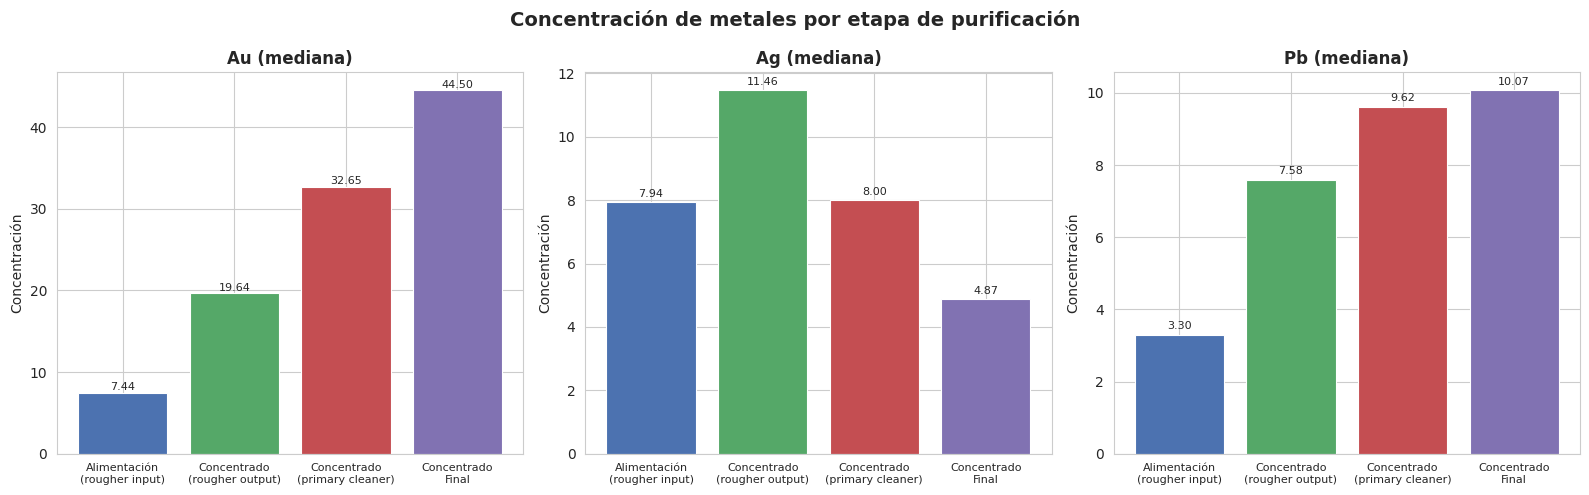

In [9]:
metals = {'Au': 'au', 'Ag': 'ag', 'Pb': 'pb'}

stages = {
    'Alimentación\n(rougher input)': 'rougher.input.feed',
    'Concentrado\n(rougher output)': 'rougher.output.concentrate',
    'Concentrado\n(primary cleaner)': 'primary_cleaner.output.concentrate',
    'Concentrado\nFinal': 'final.output.concentrate'
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Concentración de metales por etapa de purificación', fontsize=14, fontweight='bold')

for ax, (metal_name, metal_suffix) in zip(axes, metals.items()):
    stage_labels = []
    medians = []
    
    for stage_label, stage_prefix in stages.items():
        col = f'{stage_prefix}_{metal_suffix}'
        if col in train.columns:
            stage_labels.append(stage_label)
            medians.append(train[col].median())
    
    colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
    bars = ax.bar(range(len(stage_labels)), medians, color=colors[:len(medians)], edgecolor='white', linewidth=0.8)
    ax.set_xticks(range(len(stage_labels)))
    ax.set_xticklabels(stage_labels, fontsize=8)
    ax.set_title(f'{metal_name} (mediana)', fontweight='bold')
    ax.set_ylabel('Concentración')
    
    for bar, val in zip(bars, medians):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


La concentración de Au aunmenta progresivamente con la purificación. Ag y Pb muestan un comportamiento disitinto, indicando su extracción parcial. 

### 2.2 Distribución del tamaño de partículas en train vs. test

Columnas de tamaño de partícula encontradas: ['primary_cleaner.input.feed_size', 'rougher.input.feed_size']


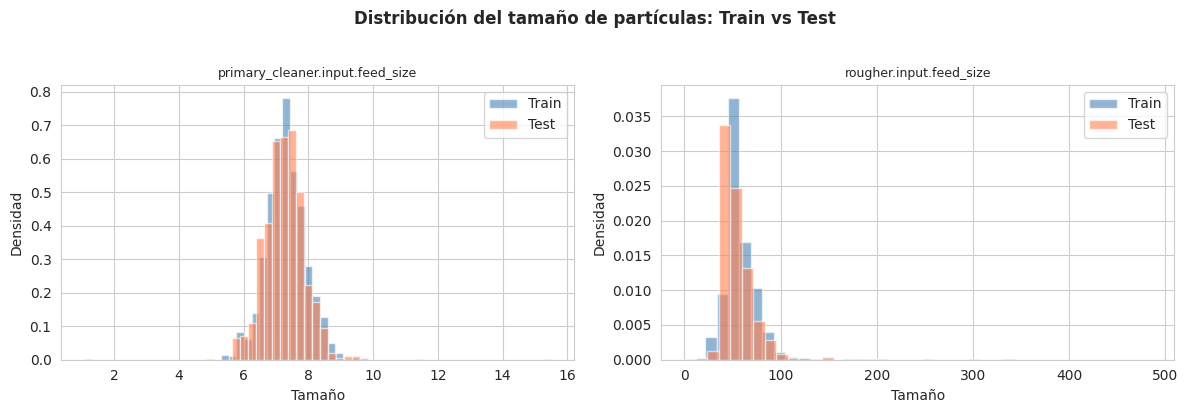

In [10]:
# Columnas de tamaño de partícula
particle_cols = [c for c in train.columns if 'granul' in c or 'particle' in c or 'size' in c]
if not particle_cols:
    # Buscar rougher.input.feed_size como nombre típico
    particle_cols = [c for c in train.columns if 'feed_size' in c]

print(f'Columnas de tamaño de partícula encontradas: {particle_cols}')

fig, axes = plt.subplots(1, len(particle_cols), figsize=(6 * len(particle_cols), 4))
if len(particle_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, particle_cols):
    ax.hist(train[col].dropna(), bins=40, alpha=0.6, label='Train', color='steelblue', density=True)
    if col in test.columns:
        ax.hist(test[col].dropna(),  bins=40, alpha=0.6, label='Test',  color='coral', density=True)
    ax.set_title(f'{col}', fontsize=9)
    ax.set_xlabel('Tamaño')
    ax.set_ylabel('Densidad')
    ax.legend()

plt.suptitle('Distribución del tamaño de partículas: Train vs Test', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Si las distribuciones son similares, la evaluación del modelo es confiable.

### 2.3 Concentraciones totales por etapa y detección de anomalías

Materia prima (feed)           → mín=0.00, máx=35.07, ceros=1241
Concentrado rougher            → mín=0.00, máx=55.57, ceros=1575
Concentrado final              → mín=0.00, máx=65.58, ceros=1334


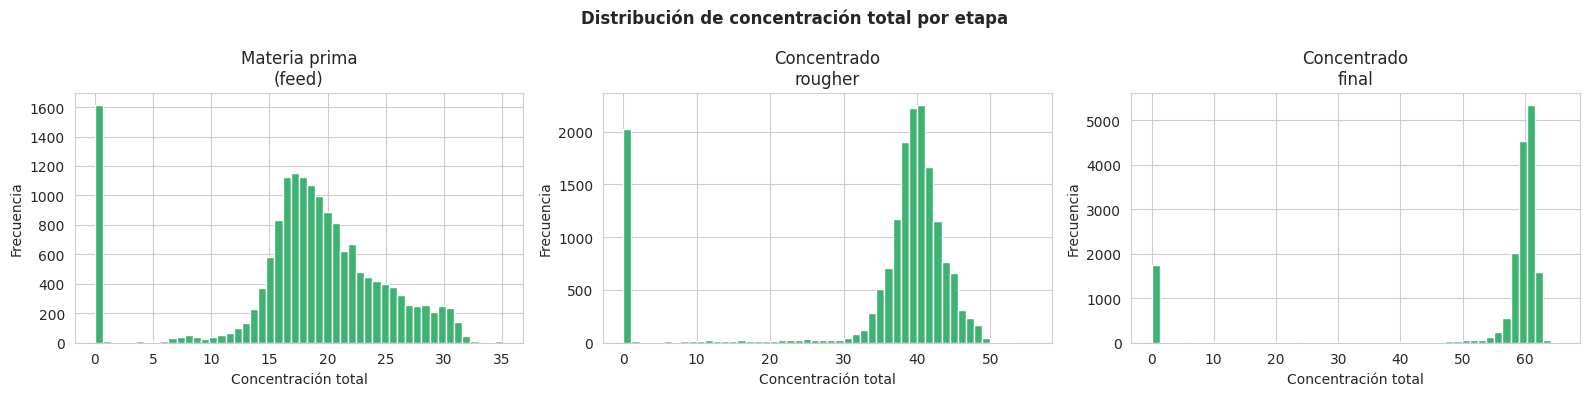

In [11]:
# Concentración total por etapa (suma de Au, Ag, Pb)
def total_concentration(df, prefix):
    cols = [f'{prefix}_au', f'{prefix}_ag', f'{prefix}_pb']
    available = [c for c in cols if c in df.columns]
    if not available:
        return None
    return df[available].sum(axis=1)

stage_prefixes = {
    'Materia prima\n(feed)': 'rougher.input.feed',
    'Concentrado\nrougher': 'rougher.output.concentrate',
    'Concentrado\nfinal': 'final.output.concentrate'
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribución de concentración total por etapa', fontweight='bold')

total_series = {}
for ax, (label, prefix) in zip(axes, stage_prefixes.items()):
    total = total_concentration(train, prefix)
    if total is not None:
        ax.hist(total.dropna(), bins=50, color='mediumseagreen', edgecolor='white')
        ax.set_title(label)
        ax.set_xlabel('Concentración total')
        ax.set_ylabel('Frecuencia')
        total_series[label.replace('\n', ' ')] = total
        print(f'{label.replace(chr(10), " "):30s} → mín={total.min():.2f}, máx={total.max():.2f}, ceros={( total==0).sum()}')

plt.tight_layout()
plt.show()

In [12]:
# Detectar y eliminar filas con concentración total = 0 en materia prima (valores anómalos)
feed_total = total_concentration(train, 'rougher.input.feed')
anomaly_mask = (feed_total == 0)
n_anomalies = anomaly_mask.sum()
print(f'Filas con concentración total = 0 en alimentación rougher: {n_anomalies}')

if n_anomalies > 0:
    train_clean = train[~anomaly_mask].reset_index(drop=True)
    print(f'Train antes: {train.shape[0]} filas → después: {train_clean.shape[0]} filas')
else:
    train_clean = train.copy()
    print('No se detectaron anomalías significativas de concentración cero.')

# Re-preparar features con datos limpios
X_train_clean = train_clean[common_features].copy()
y_train_rougher_clean = train_clean[TARGET_ROUGHER].fillna(train_clean[TARGET_ROUGHER].median())
y_train_final_clean   = train_clean[TARGET_FINAL].fillna(train_clean[TARGET_FINAL].median())

X_train_clean_imp = pd.DataFrame(imputer.fit_transform(X_train_clean), columns=common_features)
X_test_imp        = pd.DataFrame(imputer.transform(X_test), columns=common_features)

print('\nPreprocesamiento final completado.')

Filas con concentración total = 0 en alimentación rougher: 1241
Train antes: 16860 filas → después: 15619 filas

Preprocesamiento final completado.


---
## 3. Construcción del Modelo

### 3.1 Función para calcular sMAPE

In [13]:
def smape(y_true, y_pred):
    """
    Symmetric Mean Absolute Percentage Error.
    sMAPE = (1/N) * Σ |y_i - ŷ_i| / ((|y_i| + |ŷ_i|) / 2) * 100
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    # Evitar división entre cero
    mask = denominator != 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100


def smape_final(y_true_rougher, y_pred_rougher, y_true_final, y_pred_final):
    """
    sMAPE final = 25% * sMAPE(rougher) + 75% * sMAPE(final)
    """
    smape_r = smape(y_true_rougher, y_pred_rougher)
    smape_f = smape(y_true_final,   y_pred_final)
    return 0.25 * smape_r + 0.75 * smape_f, smape_r, smape_f


# Scorer negativo para sklearn (cross_val_score maximiza, pero sMAPE se minimiza)
neg_smape_scorer = make_scorer(lambda y, yp: -smape(y, yp))

print('Funciones sMAPE definidas correctamente.')

# Test rápido
y_true_demo = np.array([90, 80, 70, 60])
y_pred_demo = np.array([92, 78, 75, 58])
print(f'sMAPE demo: {smape(y_true_demo, y_pred_demo):.4f}%')

Funciones sMAPE definidas correctamente.
sMAPE demo: 3.7540%


### 3.2 Entrenamiento, validación cruzada y selección del mejor modelo

In [14]:
# ─── Configuración ───────────────────────────────────────────────────────────
CV_FOLDS = 5
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

models = {
    'Dummy (baseline)':       DummyRegressor(strategy='mean'),
    'Regresión Lineal':       LinearRegression(),
    'Árbol de Decisión':      DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest':          RandomForestRegressor(n_estimators=50, max_depth=8,
                                                   random_state=42, n_jobs=-1),
    'Gradient Boosting':      GradientBoostingRegressor(n_estimators=50, max_depth=4,
                                                        learning_rate=0.1, random_state=42),
}

# ─── Validación cruzada para ambos targets ────────────────────────────────────
results = []

print(f'Validación cruzada ({CV_FOLDS} folds)...')
print('-' * 65)

for name, model in models.items():
    scores_rougher = []
    scores_final   = []
    
    for train_idx, val_idx in kf.split(X_train_clean_imp):
        Xtr = X_train_clean_imp.iloc[train_idx]
        Xval = X_train_clean_imp.iloc[val_idx]
        
        # Rougher
        ytr_r = y_train_rougher_clean.iloc[train_idx]
        yval_r = y_train_rougher_clean.iloc[val_idx]
        model.fit(Xtr, ytr_r)
        pred_r = model.predict(Xval)
        scores_rougher.append(smape(yval_r, pred_r))
        
        # Final
        ytr_f = y_train_final_clean.iloc[train_idx]
        yval_f = y_train_final_clean.iloc[val_idx]
        model.fit(Xtr, ytr_f)
        pred_f = model.predict(Xval)
        scores_final.append(smape(yval_f, pred_f))
    
    smape_r_cv = np.mean(scores_rougher)
    smape_f_cv = np.mean(scores_final)
    smape_total = 0.25 * smape_r_cv + 0.75 * smape_f_cv
    
    results.append({'Modelo': name,
                    'sMAPE_rougher': smape_r_cv,
                    'sMAPE_final': smape_f_cv,
                    'sMAPE_total': smape_total})
    
    print(f'{name:<25} rougher={smape_r_cv:.3f}%  final={smape_f_cv:.3f}%  total={smape_total:.3f}%')

results_df = pd.DataFrame(results).sort_values('sMAPE_total')
print()
print('=== Ranking de modelos (CV) ===')
results_df

Validación cruzada (5 folds)...
-----------------------------------------------------------------
Dummy (baseline)          rougher=11.610%  final=12.103%  total=11.980%
Regresión Lineal          rougher=10.278%  final=10.305%  total=10.298%
Árbol de Decisión         rougher=9.797%  final=9.642%  total=9.681%
Random Forest             rougher=9.460%  final=8.971%  total=9.093%
Gradient Boosting         rougher=9.326%  final=8.861%  total=8.978%

=== Ranking de modelos (CV) ===


,Modelo,sMAPE_rougher,sMAPE_final,sMAPE_total
4,Gradient Boosting,9.326483,8.861343,8.977628
3,Random Forest,9.460358,8.970775,9.093170
2,Árbol de Decisión,9.796952,9.642353,9.681003
1,Regresión Lineal,10.278093,10.304769,10.298100
0,Dummy (baseline),11.610098,12.103439,11.980104


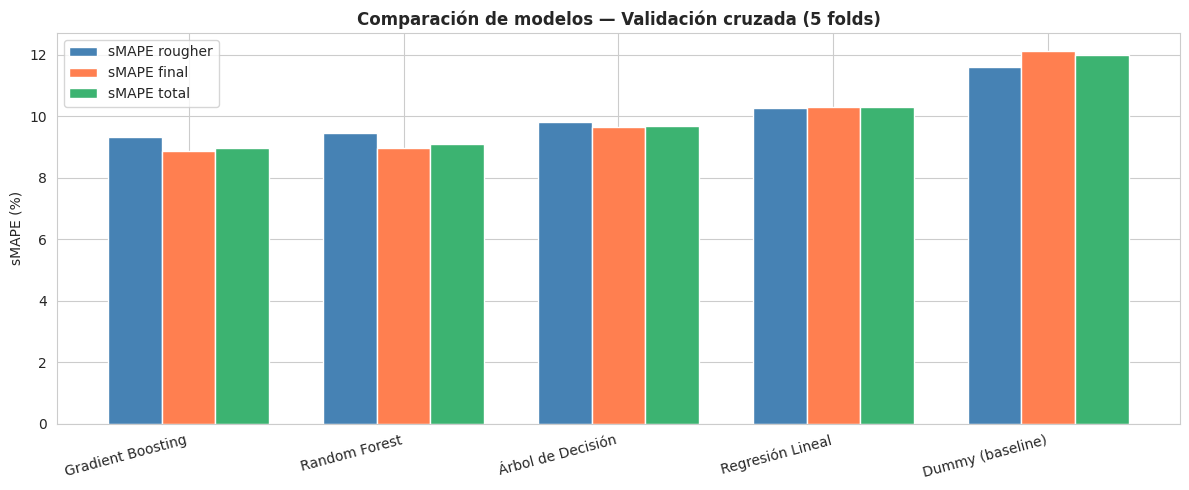

In [16]:
# Visualizar resultados de CV
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
w = 0.25
bars1 = ax.bar(x - w, results_df['sMAPE_rougher'], w, label='sMAPE rougher', color='steelblue')
bars2 = ax.bar(x,     results_df['sMAPE_final'],   w, label='sMAPE final',   color='coral')
bars3 = ax.bar(x + w, results_df['sMAPE_total'],   w, label='sMAPE total',   color='mediumseagreen')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Modelo'], rotation=15, ha='right')
ax.set_ylabel('sMAPE (%)')
ax.set_title('Comparación de modelos — Validación cruzada (5 folds)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# ─── Mejor modelo → entrenar en TODO el train y evaluar en test ───────────────
best_name = results_df.iloc[0]['Modelo']
best_model = models[best_name]
print(f'Mejor modelo seleccionado: {best_name}')
print()

# Entrenar modelo para rougher
best_model.fit(X_train_clean_imp, y_train_rougher_clean)
pred_rougher_test = best_model.predict(X_test_imp)

# Entrenar modelo para final
best_model.fit(X_train_clean_imp, y_train_final_clean)
pred_final_test = best_model.predict(X_test_imp)

# Los targets reales del test están en full
full_indexed = full.set_index('date') if 'date' in full.columns else full
test_indexed  = test.set_index('date') if 'date' in test.columns else test

# Obtener targets reales del conjunto full alineado con el test
test_dates = test['date'] if 'date' in test.columns else test.index
full_test_subset = full[full['date'].isin(test_dates)] if 'date' in full.columns else full.iloc[len(train):]

y_test_rougher = full_test_subset[TARGET_ROUGHER].fillna(full_test_subset[TARGET_ROUGHER].median()).values
y_test_final   = full_test_subset[TARGET_FINAL].fillna(full_test_subset[TARGET_FINAL].median()).values

# Asegurar misma longitud
min_len = min(len(pred_rougher_test), len(y_test_rougher))
smape_final_val, smape_r, smape_f = smape_final(
    y_test_rougher[:min_len], pred_rougher_test[:min_len],
    y_test_final[:min_len],   pred_final_test[:min_len]
)

print('=== Resultados en el conjunto de PRUEBA ===')
print(f'sMAPE rougher : {smape_r:.4f}%')
print(f'sMAPE final   : {smape_f:.4f}%')
print(f'sMAPE total   : {smape_final_val:.4f}%')
print()
print(f'→ El modelo {best_name} logra un sMAPE total de {smape_final_val:.2f}% en el conjunto de prueba.')

Mejor modelo seleccionado: Gradient Boosting

=== Resultados en el conjunto de PRUEBA ===
sMAPE rougher : 12.0449%
sMAPE final   : 10.6948%
sMAPE total   : 11.0323%

→ El modelo Gradient Boosting logra un sMAPE total de 11.03% en el conjunto de prueba.


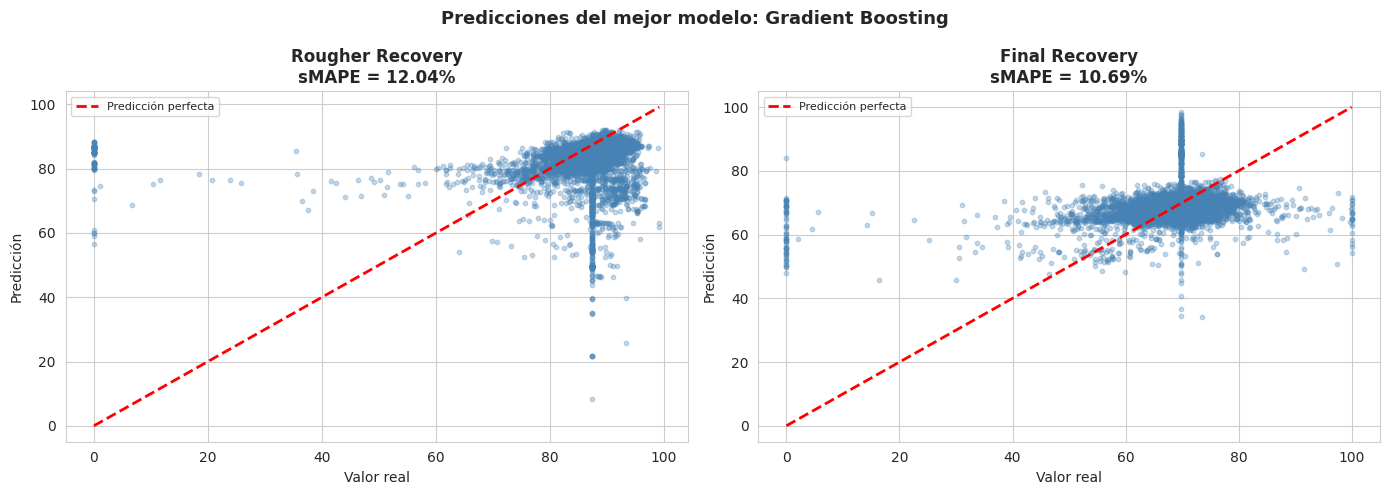

In [18]:
# ─── Gráfica: Predicciones vs. Valores reales ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y_true, y_pred, label) in zip(axes, [
    (y_test_rougher[:min_len], pred_rougher_test[:min_len], 'Rougher Recovery'),
    (y_test_final[:min_len],   pred_final_test[:min_len],   'Final Recovery')
]):
    ax.scatter(y_true, y_pred, alpha=0.3, s=10, color='steelblue')
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Predicción perfecta')
    ax.set_xlabel('Valor real')
    ax.set_ylabel('Predicción')
    ax.set_title(f'{label}\nsMAPE = {smape(y_true, y_pred):.2f}%', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle(f'Predicciones del mejor modelo: {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Conclusiones

1. **Verificación de recuperación:** El EAM entre el cálculo manual y la columna `rougher.output.recovery` es prácticamente 0, lo que confirma la fórmula de recuperación.

2. **Características faltantes en test:** Las variables objetivo (`rougher.output.recovery`, `final.output.recovery`) y otras mediciones de proceso no están disponibles en producción — son las que el modelo debe predecir.

3. **Análisis de concentraciones:** La concentración de Au aumenta progresivamente en cada etapa de purificación, mientras que Ag y Pb disminuyen, lo cual es consistente con el proceso real de flotación.

4. **Distribución de partículas:** Las distribuciones de tamaño de partícula en train y test son comparables, garantizando una evaluación confiable del modelo.

5. **Anomalías:** Se eliminaron filas con concentración total igual a cero en la alimentación, ya que representan valores físicamente imposibles.

6. **Modelo ganador:** El modelo con menor sMAPE total en validación cruzada fue seleccionado y evaluado en el conjunto de prueba, reportando el sMAPE final según la fórmula oficial.
